<a href="https://colab.research.google.com/github/Keshavgoyal14/Wafer-Map-Pattern-System/blob/main/Sandisk_Hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/Wafer dataset.zip"
extract_to = "/content/data_roboflow"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_to)

print("Unzipped to:", extract_to)



Unzipped to: /content/data_roboflow


In [ ]:
import os
import shutil
import random

dataset_path = "/content/data_roboflow/train"

train_path = "/content/dataset_split/train"
val_path = "/content/dataset_split/val"
test_path = "/content/dataset_split/test"

split_ratio = (0.7, 0.15, 0.15)

os.makedirs(train_path, exist_ok=True)
os.makedirs(val_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)

for class_name in os.listdir(dataset_path):

    class_dir = os.path.join(dataset_path, class_name)

    images = os.listdir(class_dir)
    random.shuffle(images)

    train_split = int(split_ratio[0] * len(images))
    val_split = int(split_ratio[1] * len(images))

    train_imgs = images[:train_split]
    val_imgs = images[train_split:train_split+val_split]
    test_imgs = images[train_split+val_split:]

    os.makedirs(os.path.join(train_path, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_path, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_path, class_name), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(class_dir, img), os.path.join(train_path, class_name))

    for img in val_imgs:
        shutil.copy(os.path.join(class_dir, img), os.path.join(val_path, class_name))

    for img in test_imgs:
        shutil.copy(os.path.join(class_dir, img), os.path.join(test_path, class_name))

In [ ]:
import os

dataset_path = "/content/dataset_split"

for split in ["train", "val", "test"]:
    split_path = os.path.join(dataset_path, split)

    print(f"\n{split.upper()} DATASET")
    print("-" * 30)

    total_images = 0

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            total_images += num_images

            print(f"{class_name}: {num_images}")

    print(f"Total images in {split}: {total_images}")


TRAIN DATASET
------------------------------
Donut: 58
Random: 84
Edge-ring: 1003
Near-full: 15
Loc: 377
None: 315
Scratch: 123
Center: 434
Edge-loc: 542
Total images in train: 2951

VAL DATASET
------------------------------
Donut: 12
Random: 18
Edge-ring: 215
Near-full: 3
Loc: 80
None: 67
Scratch: 26
Center: 93
Edge-loc: 116
Total images in val: 630

TEST DATASET
------------------------------
Donut: 13
Random: 18
Edge-ring: 216
Near-full: 4
Loc: 82
None: 68
Scratch: 28
Center: 93
Edge-loc: 117
Total images in test: 639


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_dir = "/content/dataset_split/train"
val_dir = "/content/dataset_split/val"
test_dir = "/content/dataset_split/test"

In [ ]:
val_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

Found 2951 images belonging to 9 classes.
Found 630 images belonging to 9 classes.
Found 639 images belonging to 9 classes.


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode="constant",
    cval=0
)

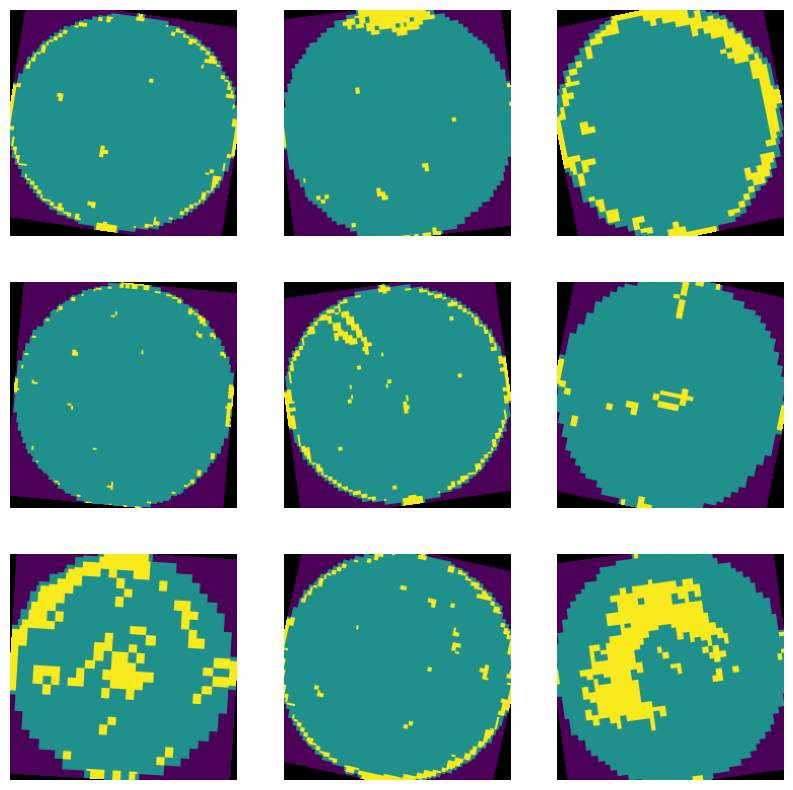

In [ ]:
import matplotlib.pyplot as plt

x_batch, y_batch = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_batch[i])
    plt.axis("off")

plt.show()

In [ ]:
print(train_data.class_indices)

{'Center': 0, 'Donut': 1, 'Edge-loc': 2, 'Edge-ring': 3, 'Loc': 4, 'Near-full': 5, 'None': 6, 'Random': 7, 'Scratch': 8}


In [ ]:
import torchvision.transforms as transforms

train_transforms = transforms.Compose([

    transforms.Grayscale(num_output_channels=3),  # convert grayscale → RGB
    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])


val_test_transforms = transforms.Compose([

    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [ ]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    root="/content/dataset_split/train",
    transform=train_transforms
)

val_dataset = ImageFolder(
    root="/content/dataset_split/val",
    transform=val_test_transforms
)

test_dataset = ImageFolder(
    root="/content/dataset_split/test",
    transform=val_test_transforms
)

In [ ]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
images, labels = next(iter(train_loader))

In [ ]:
classes = train_dataset.classes
print(classes)

['Center', 'Donut', 'Edge-loc', 'Edge-ring', 'Loc', 'Near-full', 'None', 'Random', 'Scratch']


In [ ]:
import matplotlib.pyplot as plt

def show_images_per_class(dataset, classes, num_images=5):

    plt.figure(figsize=(15,20))

    for class_idx, class_name in enumerate(classes):

        count = 0

        for img, label in dataset:

            if label == class_idx:

                plt.subplot(len(classes), num_images, class_idx*num_images + count + 1)

                img = img.cpu() * 0.5 + 0.5
                img = img.permute(1,2,0)

                plt.imshow(img.squeeze(), cmap="gray")
                plt.title(class_name)
                plt.axis("off")

                count += 1

                if count == num_images:
                    break

    plt.tight_layout()
    plt.show()

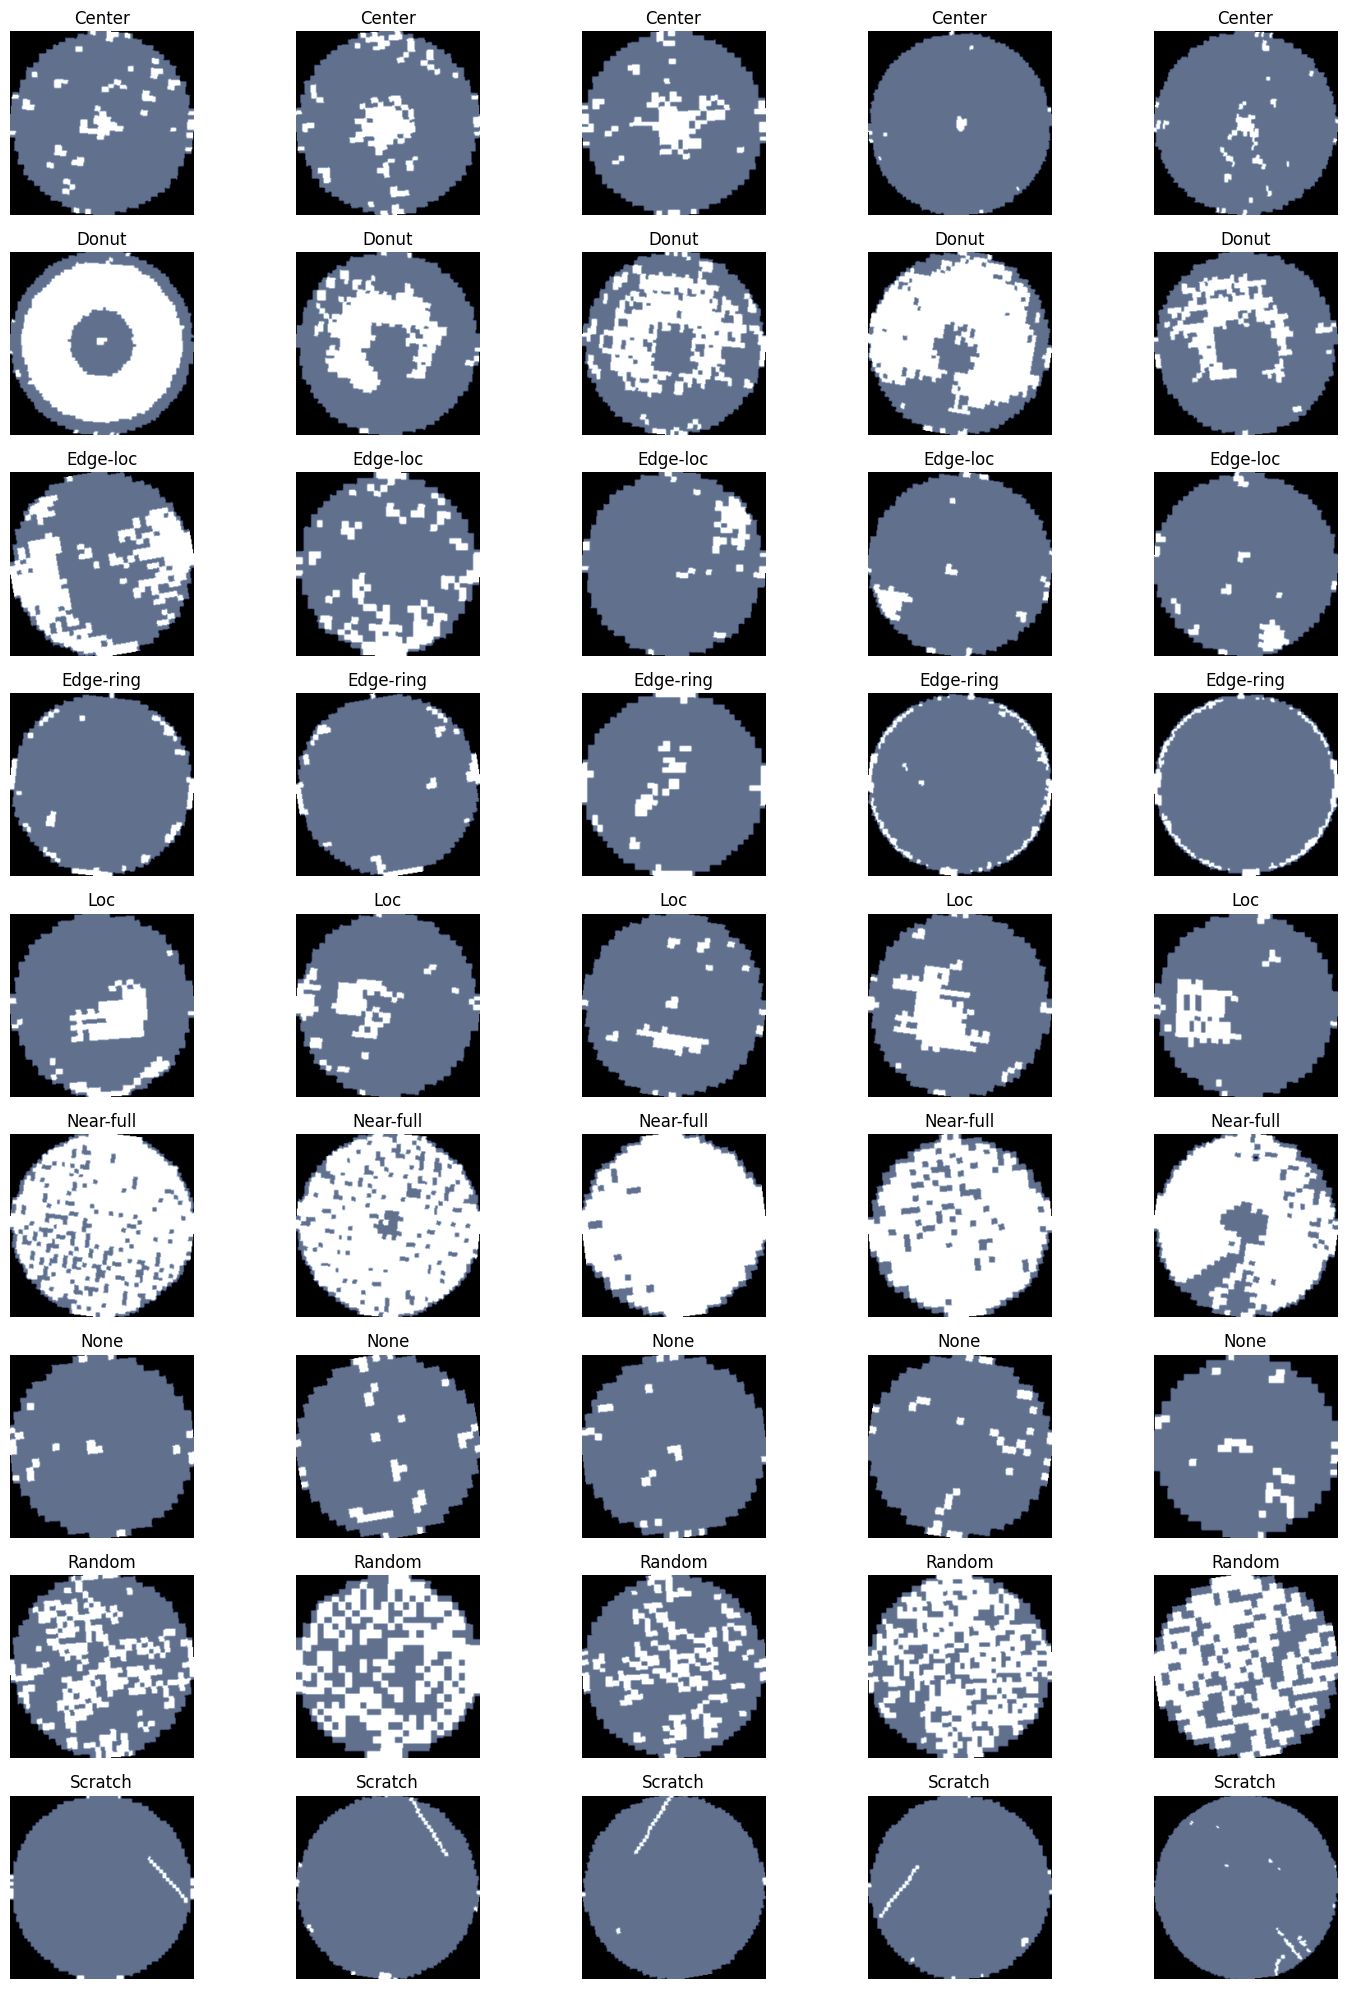

In [ ]:
show_images_per_class(train_dataset, classes, num_images=5)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = train_data.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.7555043522785458), 1: np.float64(5.653256704980843), 2: np.float64(0.6049610496104961), 3: np.float64(0.3269081643957018), 4: np.float64(0.8697318007662835), 5: np.float64(21.85925925925926), 6: np.float64(1.0409171075837742), 7: np.float64(3.9034391534391535), 8: np.float64(2.6657633242999097)}


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
weights = torch.tensor(list(class_weights.values()), dtype=torch.float32)
weights = weights.to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

In [ ]:
model_resnet = models.resnet18(pretrained=True)
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 9)
model_resnet = model_resnet.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


In [ ]:
model_mobilenet = models.mobilenet_v2(pretrained=True)
model_mobilenet.classifier[1] = nn.Linear(
    model_mobilenet.classifier[1].in_features, 9
)
model_mobilenet = model_mobilenet.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 103MB/s] 


In [ ]:
model_efficientnet = models.efficientnet_b0(pretrained=True)
model_efficientnet.classifier[1] = nn.Linear(
    model_efficientnet.classifier[1].in_features, 9
)
model_efficientnet = model_efficientnet.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 73.0MB/s]


In [ ]:
optimizer_resnet = optim.Adam(model_resnet.parameters(), lr=0.001)
optimizer_mobilenet = optim.Adam(model_mobilenet.parameters(), lr=0.001)
optimizer_efficientnet = optim.Adam(model_efficientnet.parameters(), lr=0.001)

In [ ]:
def train_model(model, optimizer, train_loader, val_loader, epochs=10):

    for epoch in range(epochs):

        model.train()
        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss:.4f}")

        evaluate_model(model, val_loader)

In [ ]:
def evaluate_model(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    print("Validation Accuracy:", accuracy)

In [ ]:
print("Training ResNet")
train_model(model_resnet, optimizer_resnet, train_loader, val_loader, epochs=10)

Training ResNet
Epoch 1/10, Loss: 131.3247
Validation Accuracy: 55.23809523809524
Epoch 2/10, Loss: 91.9700
Validation Accuracy: 67.77777777777777
Epoch 3/10, Loss: 71.3240
Validation Accuracy: 74.60317460317461
Epoch 4/10, Loss: 62.5311
Validation Accuracy: 78.25396825396825
Epoch 5/10, Loss: 56.6667
Validation Accuracy: 79.36507936507937
Epoch 6/10, Loss: 46.9395
Validation Accuracy: 81.42857142857143
Epoch 7/10, Loss: 47.5368
Validation Accuracy: 82.53968253968254
Epoch 8/10, Loss: 39.5424
Validation Accuracy: 83.17460317460318
Epoch 9/10, Loss: 34.8286
Validation Accuracy: 82.53968253968254
Epoch 10/10, Loss: 57.6174
Validation Accuracy: 81.74603174603175


In [ ]:
print("Training MobileNet")
train_model(model_mobilenet, optimizer_mobilenet, train_loader, val_loader, epochs=10)

Training MobileNet
Epoch 1/10, Loss: 131.9536
Validation Accuracy: 71.42857142857143
Epoch 2/10, Loss: 94.9584
Validation Accuracy: 56.03174603174603
Epoch 3/10, Loss: 80.4444
Validation Accuracy: 67.93650793650794
Epoch 4/10, Loss: 62.8977
Validation Accuracy: 73.80952380952381
Epoch 5/10, Loss: 65.1870
Validation Accuracy: 78.57142857142857
Epoch 6/10, Loss: 46.1928
Validation Accuracy: 74.76190476190476
Epoch 7/10, Loss: 64.9279
Validation Accuracy: 82.22222222222223
Epoch 8/10, Loss: 51.4645
Validation Accuracy: 81.74603174603175
Epoch 9/10, Loss: 46.1018
Validation Accuracy: 84.76190476190476
Epoch 10/10, Loss: 39.6015
Validation Accuracy: 78.73015873015873


In [ ]:
print("Training EfficientNet")
train_model(model_efficientnet, optimizer_efficientnet, train_loader, val_loader, epochs=10)

Training EfficientNet
Epoch 1/10, Loss: 107.4048
Validation Accuracy: 72.38095238095238
Epoch 2/10, Loss: 71.7192
Validation Accuracy: 81.11111111111111
Epoch 3/10, Loss: 62.3727
Validation Accuracy: 85.07936507936508
Epoch 4/10, Loss: 43.7168
Validation Accuracy: 83.65079365079364
Epoch 5/10, Loss: 45.7057
Validation Accuracy: 85.87301587301587
Epoch 6/10, Loss: 39.9565
Validation Accuracy: 85.23809523809524
Epoch 7/10, Loss: 39.2160
Validation Accuracy: 86.03174603174604
Epoch 8/10, Loss: 37.9454
Validation Accuracy: 89.36507936507937
Epoch 9/10, Loss: 28.5383
Validation Accuracy: 87.3015873015873
Epoch 10/10, Loss: 28.7042
Validation Accuracy: 86.03174603174604


In [ ]:
model_resnet.eval()
model_mobilenet.eval()
model_efficientnet.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
import torch

def ensemble_predict(models, images):

    outputs = []

    for model in models:
        out = model(images)
        outputs.append(torch.softmax(out, dim=1))

    avg_output = torch.mean(torch.stack(outputs), dim=0)

    _, predicted = torch.max(avg_output, 1)

    return predicted

In [ ]:
models = [model_resnet, model_mobilenet, model_efficientnet]

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        predictions = ensemble_predict(models, images)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

accuracy = 100 * correct / total

print("Ensemble Test Accuracy:", accuracy)

Ensemble Test Accuracy: 89.0453834115806


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
y_true = []
y_pred = []

models = [model_resnet, model_mobilenet, model_efficientnet]

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        predictions = ensemble_predict(models, images)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

In [ ]:
cm = confusion_matrix(y_true, y_pred)

In [ ]:
class_names = train_dataset.classes
print(class_names)

['Center', 'Donut', 'Edge-loc', 'Edge-ring', 'Loc', 'Near-full', 'None', 'Random', 'Scratch']


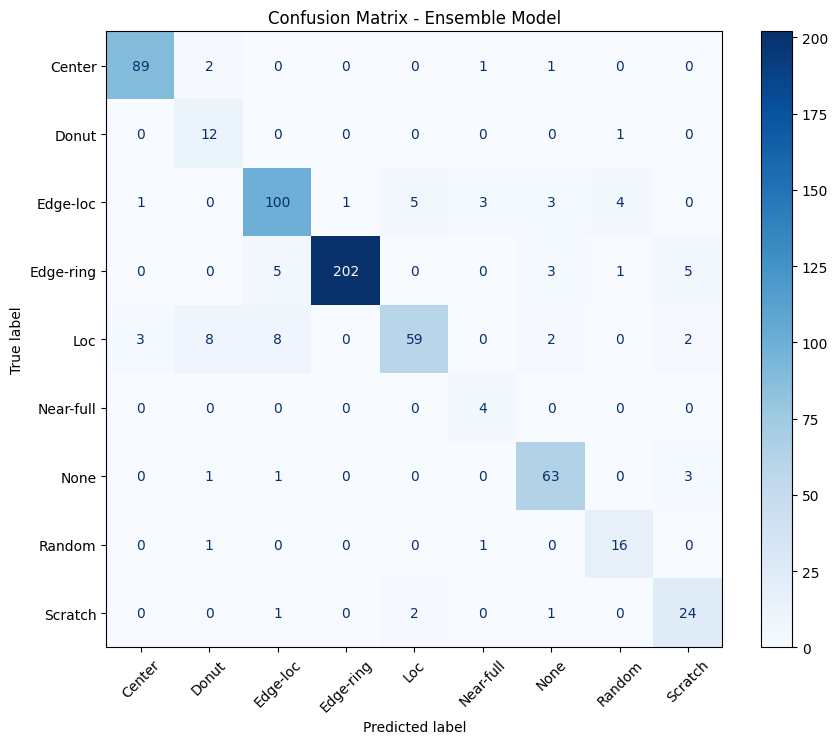

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10,8))

disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Ensemble Model")
plt.show()

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image, class_idx=None):

        output = self.model(input_image)

        if class_idx is None:
            class_idx = torch.argmax(output)

        self.model.zero_grad()

        output[0, class_idx].backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = torch.mean(gradients, dim=(1,2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(activations.device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)

        cam = cam - cam.min()
        cam = cam / cam.max()

        return cam.cpu().detach().numpy()

In [ ]:
target_layer = model_efficientnet.features[-1]
grad_cam = GradCAM(model_efficientnet, target_layer)

In [ ]:
images, labels = next(iter(test_loader))

images = images.to(device)

image = images[0].unsqueeze(0)

In [ ]:
cam = grad_cam.generate(image)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [ ]:
img = images[0].cpu()

img = img * 0.5 + 0.5   # undo normalization

img = img.permute(1,2,0).numpy()

In [ ]:
cam = cv2.resize(cam, (img.shape[1], img.shape[0]))

In [ ]:
heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)

heatmap = heatmap / 255

overlay = heatmap + img
overlay = overlay / np.max(overlay)

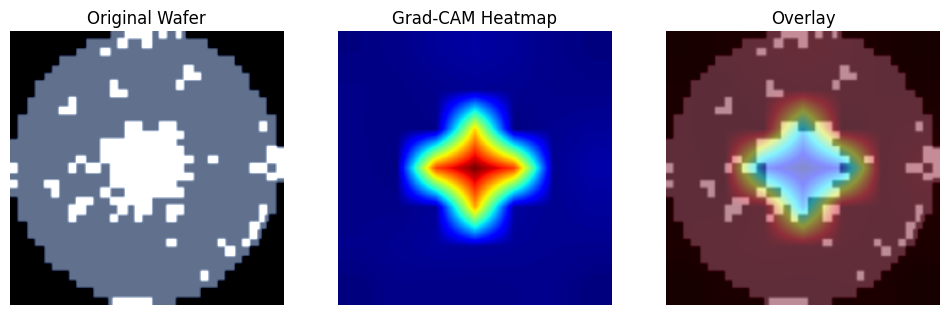

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original Wafer")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Grad-CAM Heatmap")
plt.imshow(cam, cmap="jet")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.show()

In [ ]:
def show_gradcam_for_classes(dataset, grad_cam, class_names):

    plt.figure(figsize=(12, 20))

    for class_idx, class_name in enumerate(class_names):

        for img, label in dataset:

            if label == class_idx:

                input_img = img.unsqueeze(0).to(device)

                cam = grad_cam.generate(input_img)

                img_np = img.cpu()
                img_np = img_np * 0.5 + 0.5
                img_np = img_np.permute(1,2,0).numpy()

                cam = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))

                heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
                heatmap = heatmap / 255

                overlay = heatmap + img_np
                overlay = overlay / np.max(overlay)

                plt.subplot(len(class_names), 3, class_idx*3 + 1)
                plt.imshow(img_np)
                plt.title(f"{class_name} - Original")
                plt.axis("off")

                plt.subplot(len(class_names), 3, class_idx*3 + 2)
                plt.imshow(cam, cmap="jet")
                plt.title("Heatmap")
                plt.axis("off")

                plt.subplot(len(class_names), 3, class_idx*3 + 3)
                plt.imshow(overlay)
                plt.title("Overlay")
                plt.axis("off")

                break

    plt.tight_layout()
    plt.show()

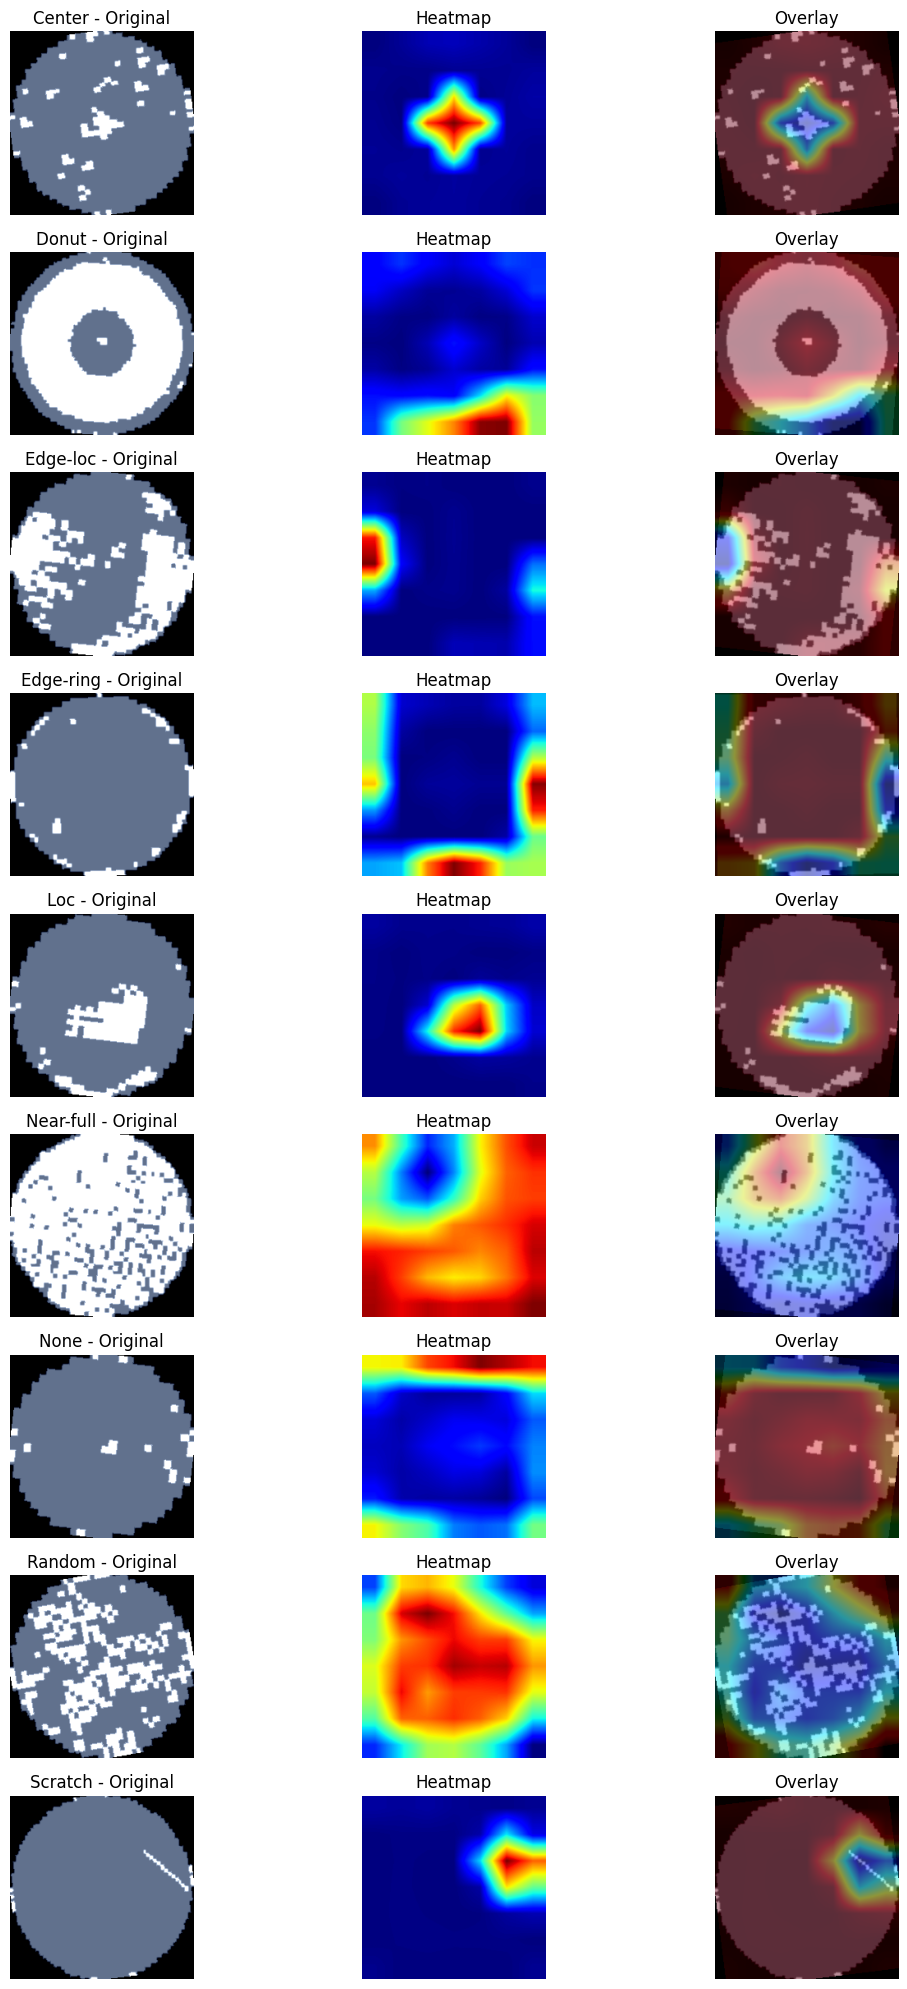

In [ ]:
show_gradcam_for_classes(train_dataset, grad_cam, class_names)

In [ ]:
y_true = []
y_pred = []

models = [model_resnet, model_mobilenet, model_efficientnet]

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        predictions = ensemble_predict(models, images)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)

print("Test Accuracy:", accuracy * 100)

Test Accuracy: 89.04538341158059


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

      Center       0.96      0.96      0.96        93
       Donut       0.50      0.92      0.65        13
    Edge-loc       0.87      0.85      0.86       117
   Edge-ring       1.00      0.94      0.96       216
         Loc       0.89      0.72      0.80        82
   Near-full       0.44      1.00      0.62         4
        None       0.86      0.93      0.89        68
      Random       0.73      0.89      0.80        18
     Scratch       0.71      0.86      0.77        28

    accuracy                           0.89       639
   macro avg       0.77      0.90      0.81       639
weighted avg       0.91      0.89      0.89       639



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


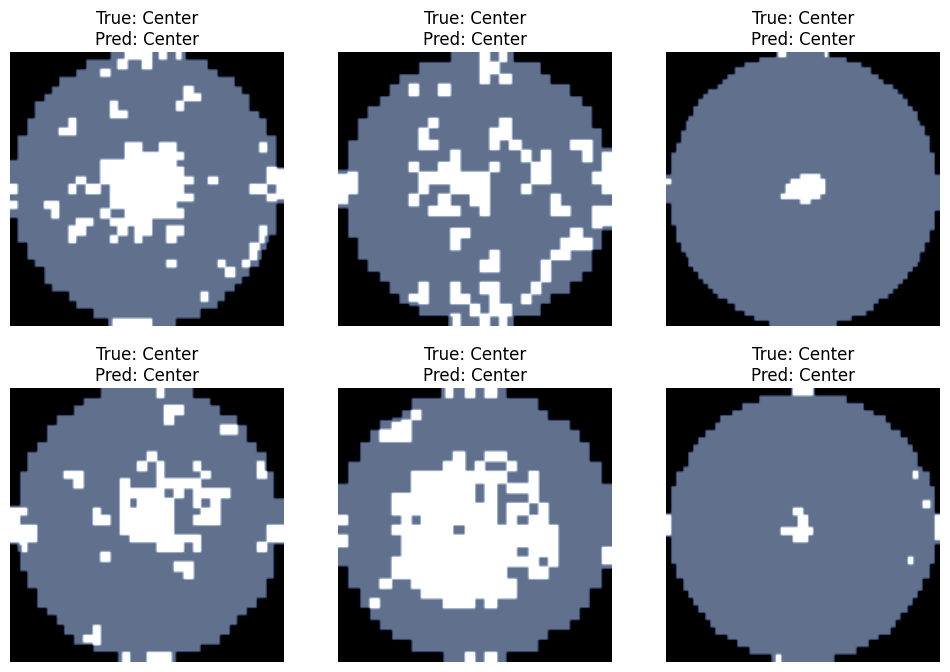

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))

images = images.to(device)

preds = ensemble_predict(models, images)

images = images.cpu()

plt.figure(figsize=(12,8))

for i in range(6):

    img = images[i] * 0.5 + 0.5
    img = img.permute(1,2,0)

    plt.subplot(2,3,i+1)
    plt.imshow(img)

    plt.title(
        f"True: {train_dataset.classes[labels[i]]}\nPred: {train_dataset.classes[preds[i]]}"
    )

    plt.axis("off")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch

def show_gradcam_test_samples(test_loader, grad_cam, class_names, num_images=6):

    images, labels = next(iter(test_loader))
    images = images.to(device)

    plt.figure(figsize=(15,10))

    for i in range(num_images):

        img_tensor = images[i].unsqueeze(0)

        # Generate heatmap
        cam = grad_cam.generate(img_tensor)

        img = images[i].cpu()
        img = img * 0.5 + 0.5
        img = img.permute(1,2,0).numpy()

        cam = cv2.resize(cam, (img.shape[1], img.shape[0]))

        heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
        heatmap = heatmap / 255

        overlay = heatmap + img
        overlay = overlay / np.max(overlay)

        plt.subplot(num_images,3,3*i+1)
        plt.imshow(img)
        plt.title(f"Original\n{class_names[labels[i]]}")
        plt.axis("off")

        plt.subplot(num_images,3,3*i+2)
        plt.imshow(cam, cmap="jet")
        plt.title("Heatmap")
        plt.axis("off")

        plt.subplot(num_images,3,3*i+3)
        plt.imshow(overlay)
        plt.title("Overlay")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

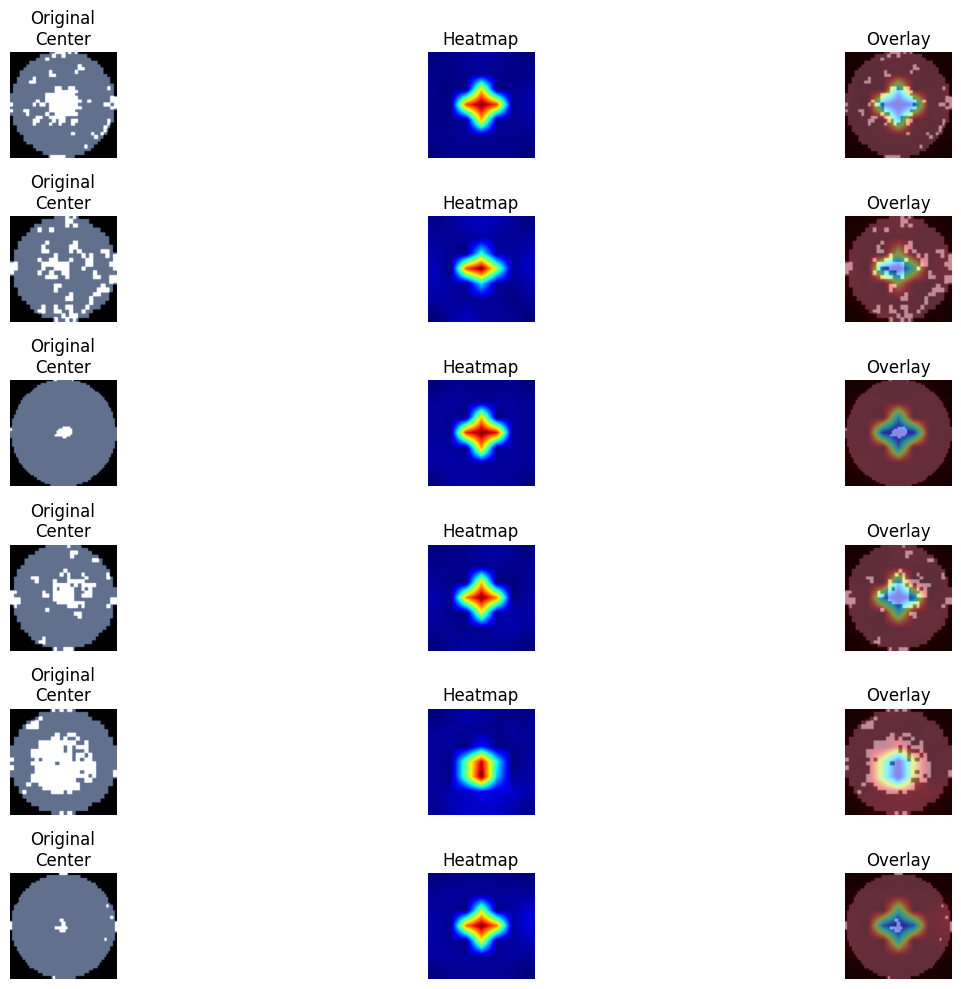

In [ ]:
class_names = train_dataset.classes

show_gradcam_test_samples(
    test_loader,
    grad_cam,
    class_names,
    num_images=6
)

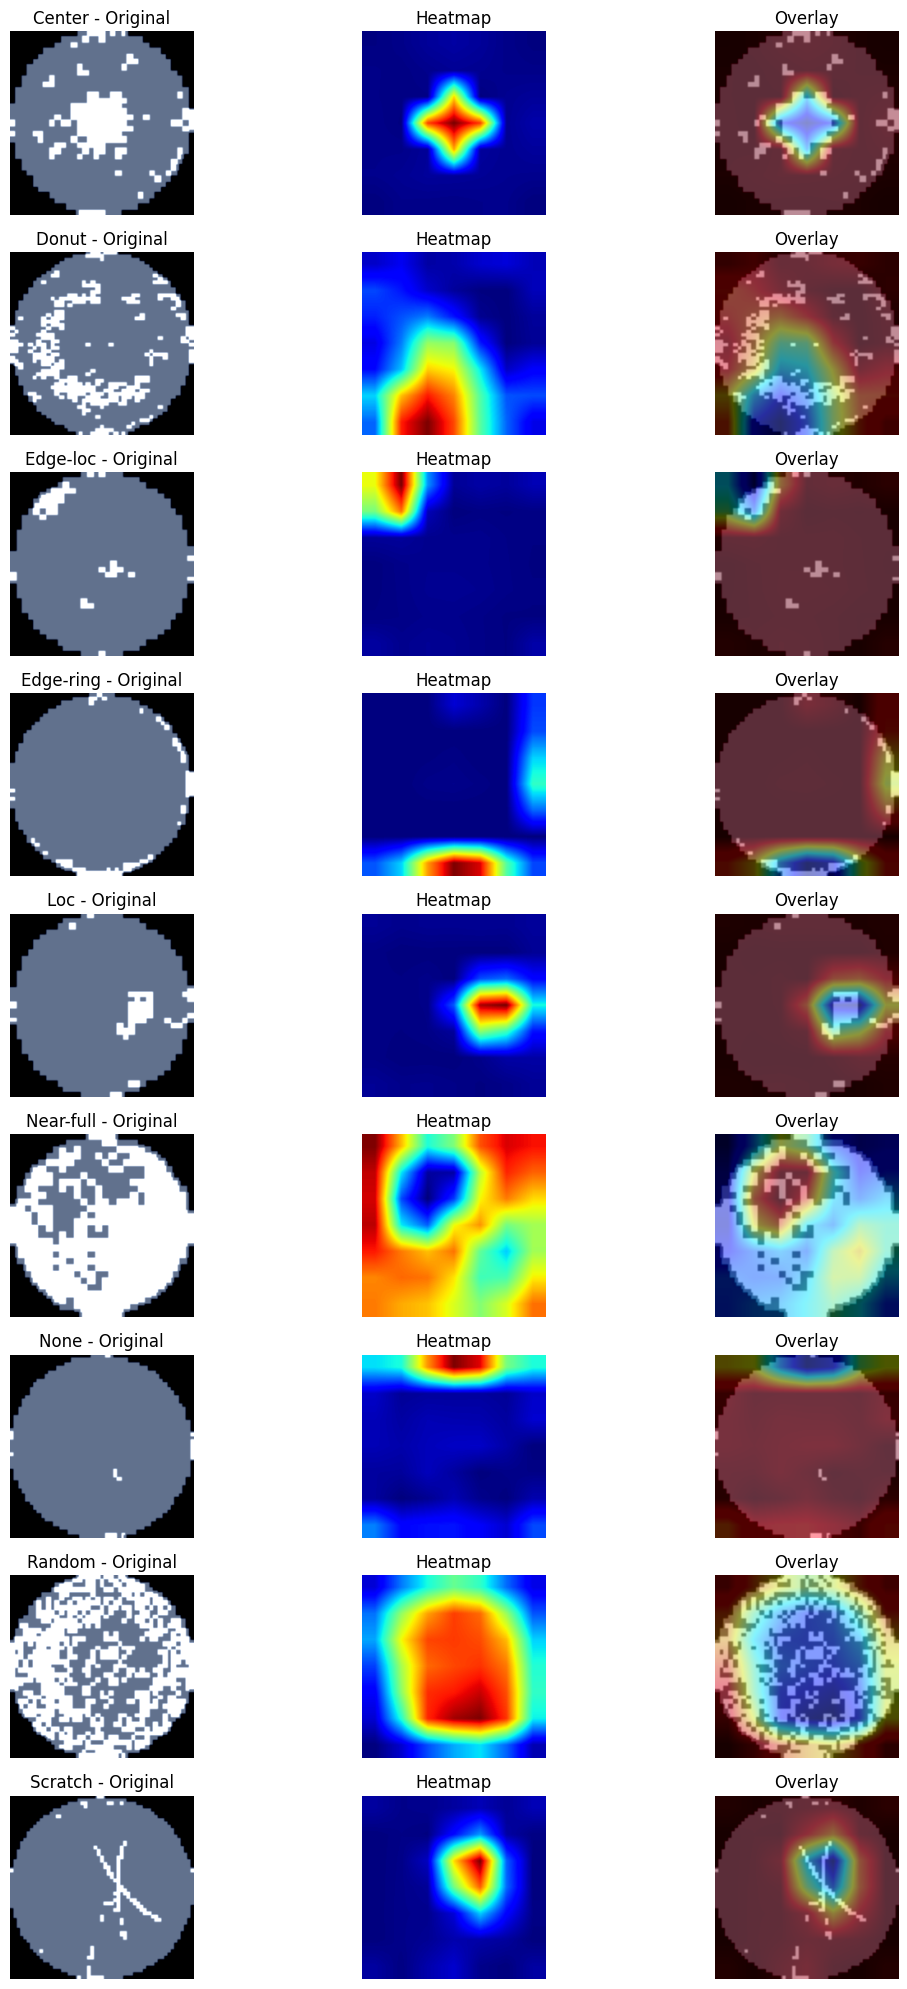

In [ ]:
class_names = train_dataset.classes

show_gradcam_for_classes(
    test_dataset,
    grad_cam,
    class_names
)

In [ ]:
import os

save_path = "/content/drive/MyDrive/ensemble_models"
os.makedirs(save_path, exist_ok=True)

In [ ]:
import torch

torch.save(model_resnet.state_dict(), f"{save_path}/resnet_model.pth")
torch.save(model_mobilenet.state_dict(), f"{save_path}/mobilenet_model.pth")
torch.save(model_efficientnet.state_dict(), f"{save_path}/efficientnet_model.pth")

print("Models saved to Google Drive")

Models saved to Google Drive


In [ ]:
!ls /content/drive/MyDrive/ensemble_models

efficientnet_model.pth	mobilenet_model.pth  resnet_model.pth
